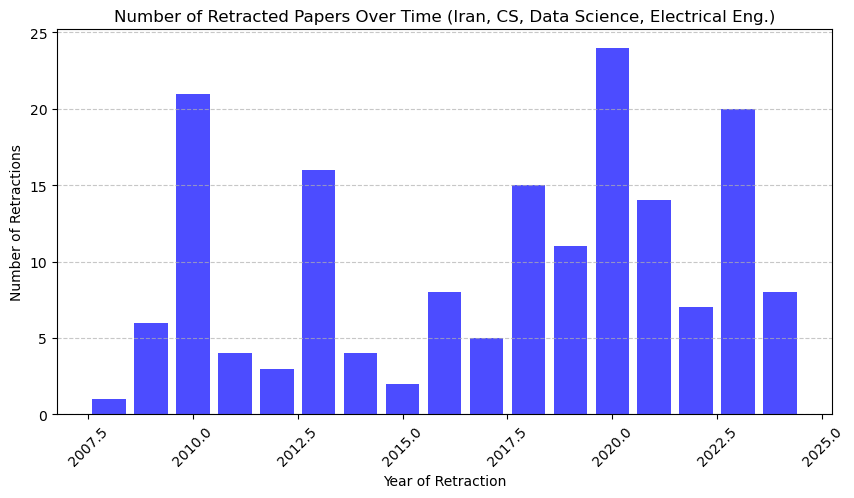

count    169.000000
mean       2.863905
std        3.321888
min        0.000000
25%        0.000000
50%        2.000000
75%        4.000000
max       15.000000
Name: RetractionLag, dtype: float64

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec.csv")

# Convert date columns to datetime format
df["RetractionDate"] = pd.to_datetime(df["RetractionDate"], errors='coerce')
df["OriginalPaperDate"] = pd.to_datetime(df["OriginalPaperDate"], errors='coerce')

# Extract year of retraction and original publication
df["RetractionYear"] = df["RetractionDate"].dt.year
df["OriginalYear"] = df["OriginalPaperDate"].dt.year

# Calculate retraction time lag (years between publication and retraction)
df["RetractionLag"] = df["RetractionYear"] - df["OriginalYear"]

# Count number of retractions per year
retractions_per_year = df["RetractionYear"].value_counts().sort_index()

# Plot number of retractions per year
plt.figure(figsize=(10, 5))
plt.bar(retractions_per_year.index, retractions_per_year.values, color="blue", alpha=0.7)
plt.xlabel("Year of Retraction")
plt.ylabel("Number of Retractions")
plt.title("Number of Retracted Papers Over Time (Iran, CS, Data Science, Electrical Eng.)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Display retraction time lag statistics
df["RetractionLag"].describe()

In [5]:
retractions_per_year.values

array([ 1,  6, 21,  4,  3, 16,  4,  2,  8,  5, 15, 11, 24, 14,  7, 20,  8],
      dtype=int64)

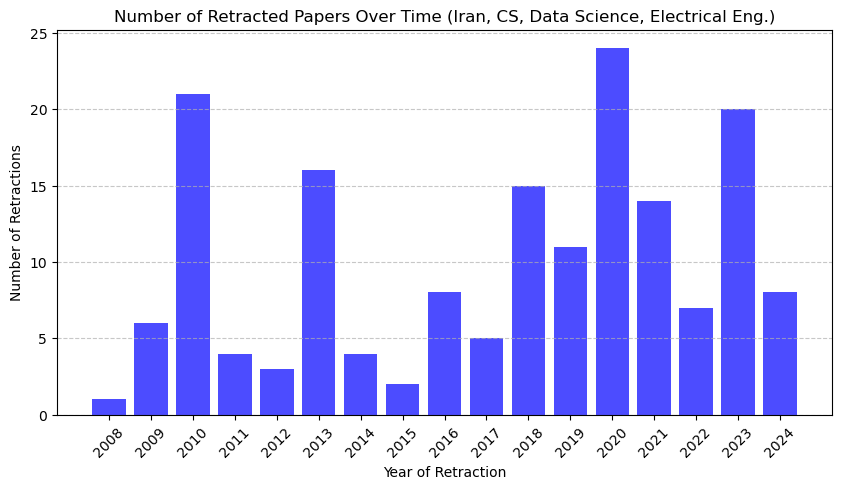

count    169.000000
mean       2.863905
std        3.321888
min        0.000000
25%        0.000000
50%        2.000000
75%        4.000000
max       15.000000
Name: RetractionLag, dtype: float64

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec.csv")

# Convert date columns to datetime format
df["RetractionDate"] = pd.to_datetime(df["RetractionDate"], errors='coerce')
df["OriginalPaperDate"] = pd.to_datetime(df["OriginalPaperDate"], errors='coerce')

# Extract year of retraction and original publication
df["RetractionYear"] = df["RetractionDate"].dt.year
df["OriginalYear"] = df["OriginalPaperDate"].dt.year

# Calculate retraction time lag (years between publication and retraction)
df["RetractionLag"] = df["RetractionYear"] - df["OriginalYear"]

# Count number of retractions per year
retractions_per_year = df["RetractionYear"].value_counts().sort_index()

# Plot number of retractions per year
plt.figure(figsize=(10, 5))
plt.bar(retractions_per_year.index, retractions_per_year.values, color="blue", alpha=0.7)

# Ensure the x-axis has only whole numbers
plt.xticks(ticks=np.arange(int(retractions_per_year.index.min()), int(retractions_per_year.index.max()) + 1, 1))

plt.xlabel("Year of Retraction")
plt.ylabel("Number of Retractions")
plt.title("Number of Retracted Papers Over Time (Iran, CS, Data Science, Electrical Eng.)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Display retraction time lag statistics
df["RetractionLag"].describe()


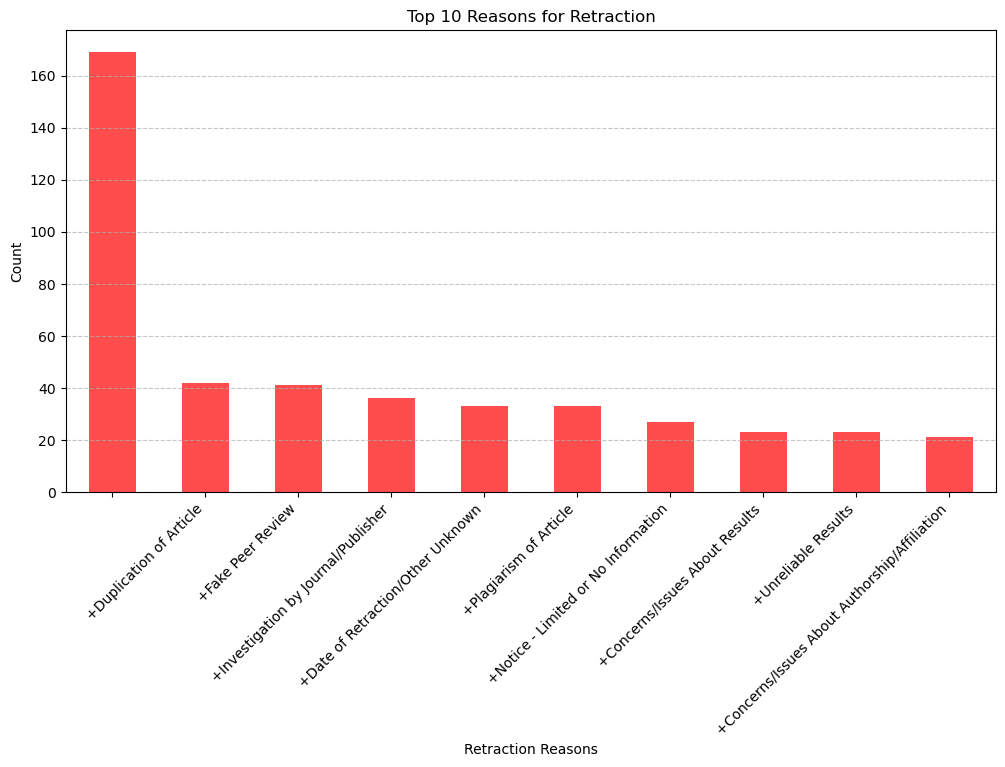

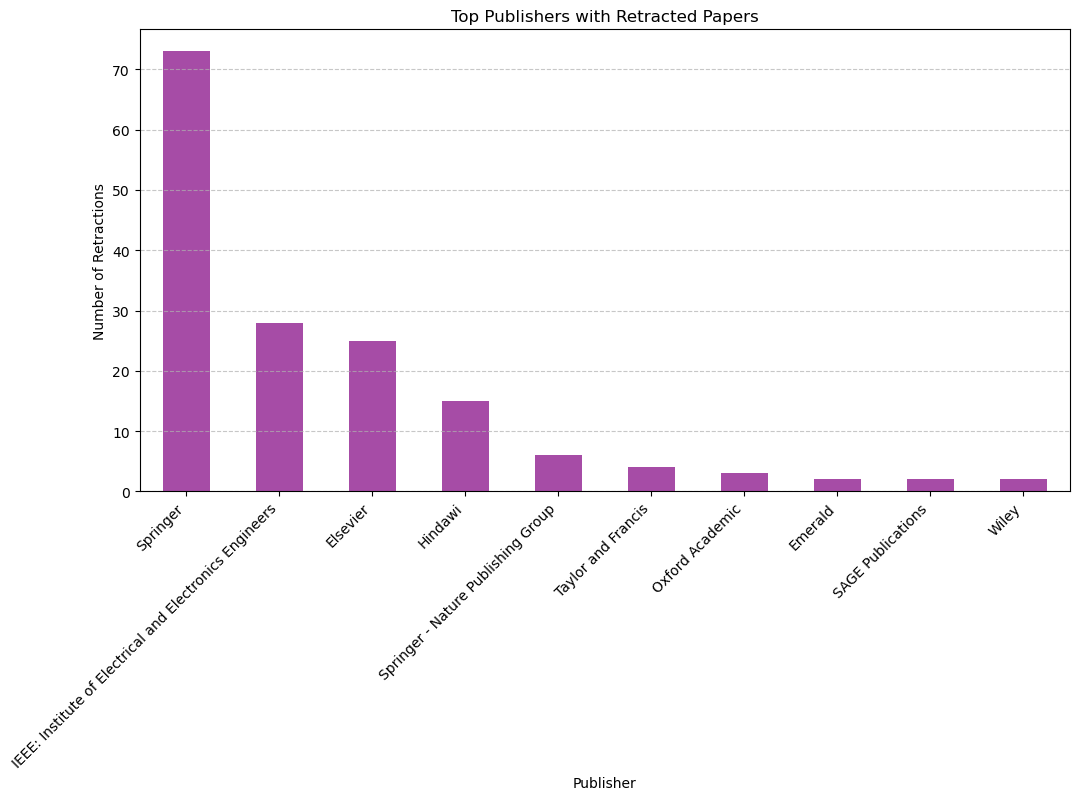

In [7]:
# Count occurrences of retraction reasons
retraction_reasons = df["Reason"].str.split(";", expand=True).stack().str.strip().value_counts()

# Plot reasons for retractions
plt.figure(figsize=(12, 6))
retraction_reasons[:10].plot(kind="bar", color="red", alpha=0.7)
plt.xlabel("Retraction Reasons")
plt.ylabel("Count")
plt.title("Top 10 Reasons for Retraction")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Count occurrences of publishers
publisher_counts = df["Publisher"].value_counts()

# Plot publishers involved in retractions
plt.figure(figsize=(12, 6))
publisher_counts[:10].plot(kind="bar", color="purple", alpha=0.7)
plt.xlabel("Publisher")
plt.ylabel("Number of Retractions")
plt.title("Top Publishers with Retracted Papers")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

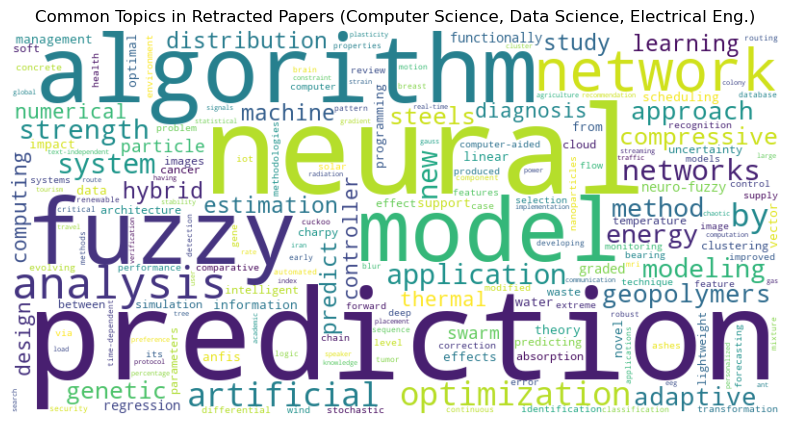

[('prediction', 26),
 ('neural', 25),
 ('algorithm', 22),
 ('fuzzy', 20),
 ('model', 19),
 ('network', 18),
 ('analysis', 17),
 ('optimization', 17),
 ('artificial', 17),
 ('by', 16)]

In [8]:
from collections import Counter
from wordcloud import WordCloud

# Extract keywords from the titles of retracted papers
all_titles = " ".join(df["Title"].dropna()).lower()

# Tokenize and count word frequencies (excluding common stopwords)
stopwords = {"the", "of", "and", "in", "for", "on", "with", "a", "to", "an", "using", "based"}
words = [word for word in all_titles.split() if word not in stopwords]
word_counts = Counter(words)

# Generate a word cloud for visualization
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_counts)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Topics in Retracted Papers (Computer Science, Data Science, Electrical Eng.)")
plt.show()

# Display top 10 most common keywords
word_counts.most_common(10)

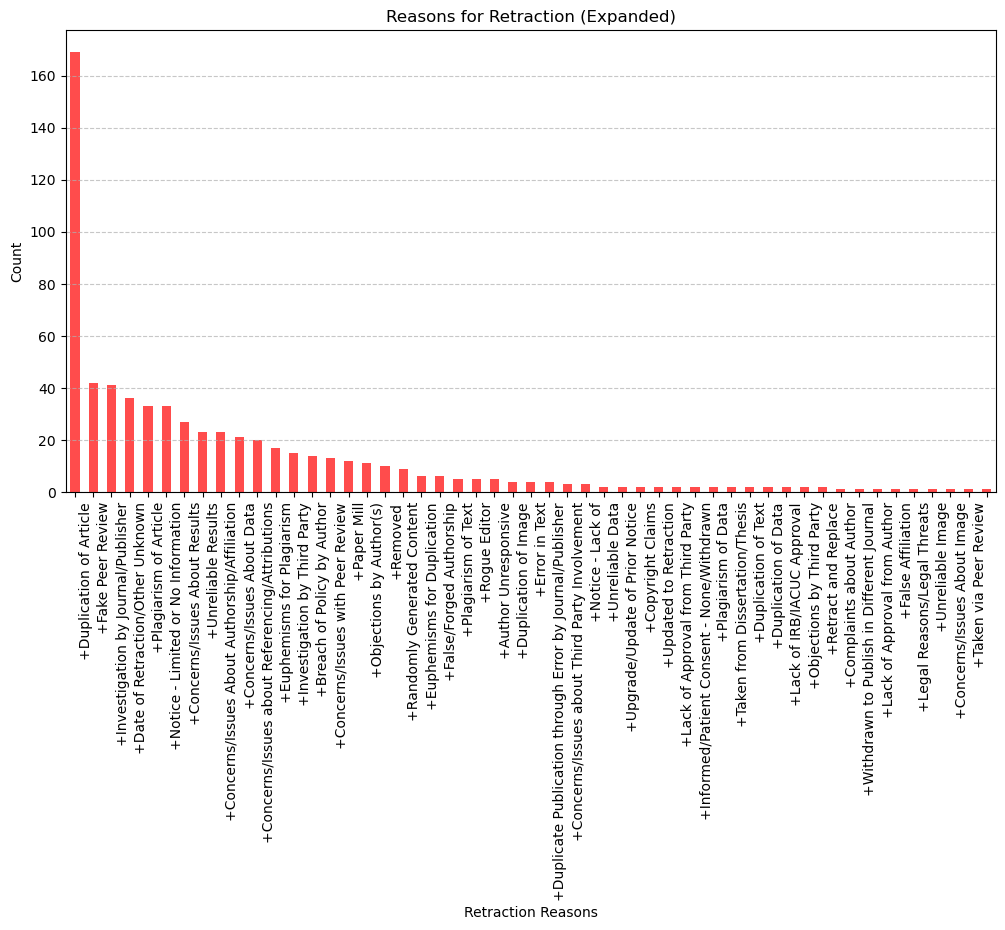

In [9]:
# Re-process retraction reasons with multiple entries per row

# Split reasons into multiple rows and count occurrences
retraction_reasons_expanded = df["Reason"].str.split(";", expand=True).stack().str.strip()
retraction_reasons_counts = retraction_reasons_expanded.value_counts()

# Plot reasons for retractions with improved labeling
plt.figure(figsize=(12, 6))
retraction_reasons_counts.plot(kind="bar", color="red", alpha=0.7)
plt.xlabel("Retraction Reasons")
plt.ylabel("Count")
plt.title("Reasons for Retraction (Expanded)")
plt.xticks(rotation=45, ha="right")

# Ensure left-most bar has a proper label
plt.xticks(ticks=range(len(retraction_reasons_counts)), labels=retraction_reasons_counts.index, rotation=90, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

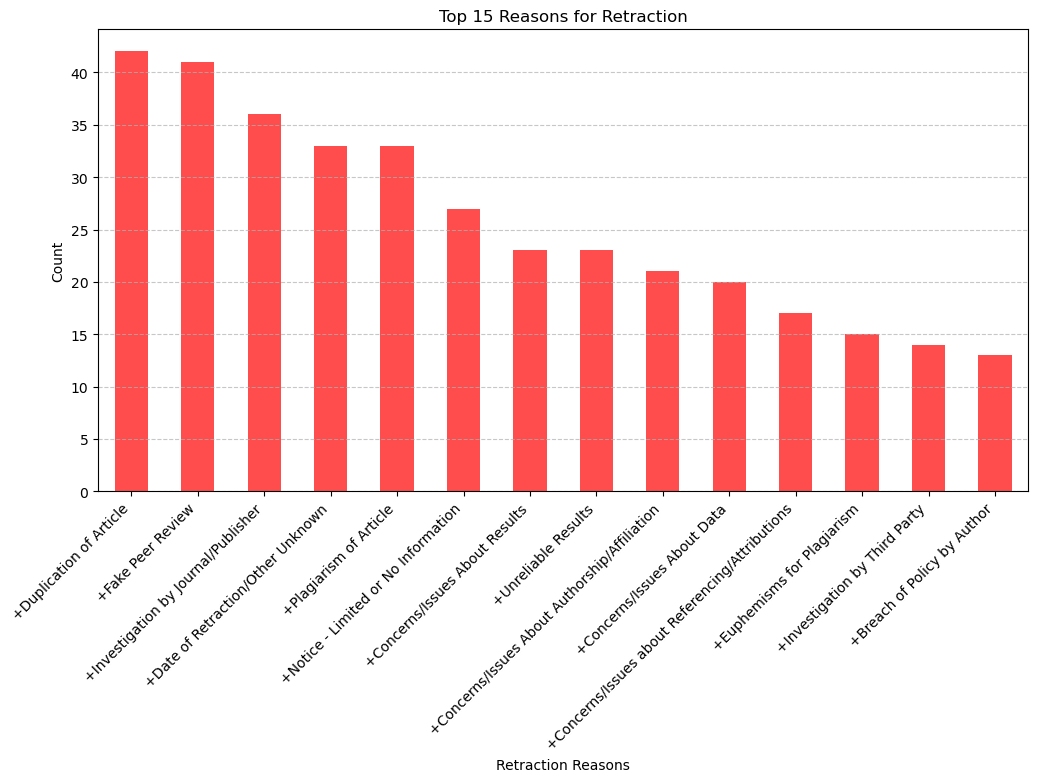

In [11]:
# Select top 15 most common retraction reasons
top_10_retraction_reasons = retraction_reasons_counts[1:15]

# Plot top 10 retraction reasons
plt.figure(figsize=(12, 6))
top_10_retraction_reasons.plot(kind="bar", color="red", alpha=0.7)
plt.xlabel("Retraction Reasons")
plt.ylabel("Count")
plt.title("Top 15 Reasons for Retraction")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [2]:
# The 'RetractionDate' column contains date values in string format.
# We'll extract the year from these dates and then group by year to count retractions.
data = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec.csv")
# Convert the 'RetractionDate' column to datetime format
data['RetractionDate'] = pd.to_datetime(data['RetractionDate'], errors='coerce')

# Extract the year from the dates
data['RetractionYear'] = data['RetractionDate'].dt.year

# Group by year and count the number of retractions
retraction_trends = data.groupby('RetractionYear').size().reset_index(name='Count')

# Sort by year for proper visualization
retraction_trends = retraction_trends.sort_values(by='RetractionYear')

# Display the trends to ensure data is correct
retraction_trends.head()

,RetractionYear,Count
0,2008,1
1,2009,6
2,2010,21
3,2011,4
4,2012,3


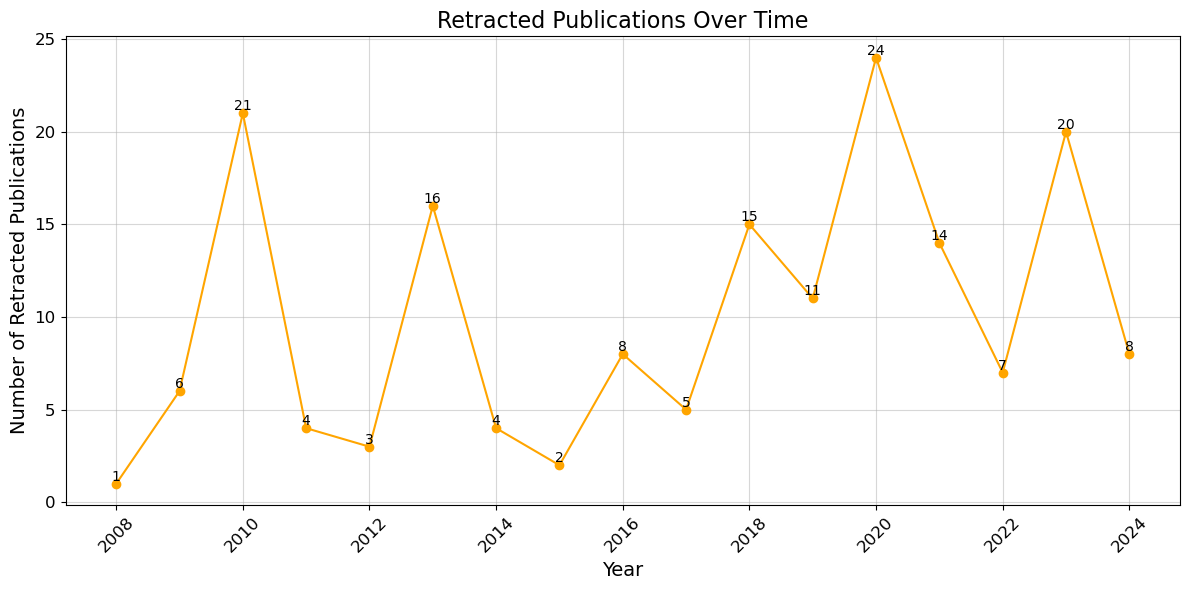

In [18]:
import matplotlib.pyplot as plt

# Generate the retraction trends chart with numbers annotated on each year

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(retraction_trends['RetractionYear'], retraction_trends['Count'], marker='o', linestyle='-', color='orange')
plt.title("Retracted Publications Over Time", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Retracted Publications", fontsize=14)
plt.grid(True, alpha=0.5)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

# Annotate each point with the count value
for _, row in retraction_trends.iterrows():
    plt.text(row['RetractionYear'], row['Count'], str(row['Count']), fontsize=10, ha='center', va='bottom')

plt.tight_layout()
plt.show()

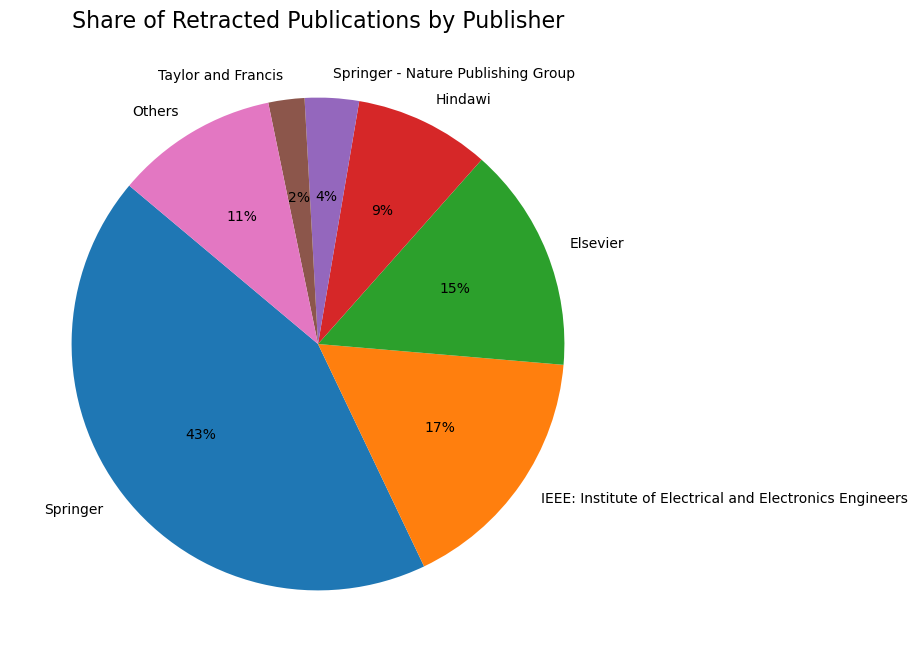

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by the 'Publisher' column and calculate the proportion of retracted publications for each publisher
publisher_counts = data['Publisher'].value_counts(normalize=True) * 100

# Select the top publishers and group others into an "Others" category
threshold = 2  # Publishers with less than 2% will be grouped into "Others"
top_publishers = publisher_counts[publisher_counts >= threshold]
others = pd.Series({'Others': publisher_counts[publisher_counts < threshold].sum()})
publisher_counts = pd.concat([top_publishers, others])

# Prepare data for the pie chart
labels = publisher_counts.index
sizes = publisher_counts.values

# Plot the pie chart
plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=labels, autopct='%1.0f%%', startangle=140, colors=plt.cm.tab10.colors)
plt.title("Share of Retracted Publications by Publisher", fontsize=16)
plt.show()

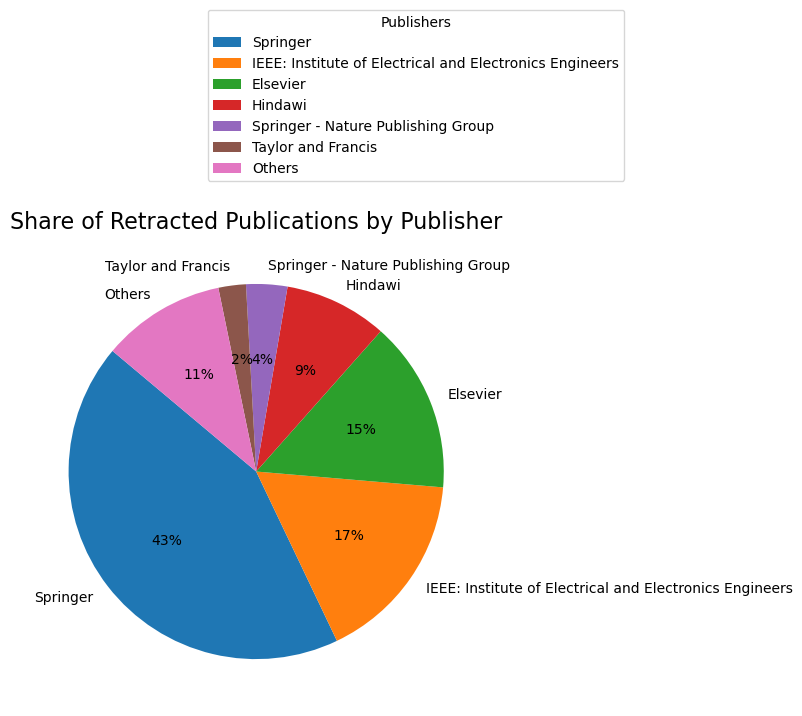

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by the 'Publisher' column and calculate the proportion of retracted publications for each publisher
publisher_counts = data['Publisher'].value_counts(normalize=True) * 100

# Select the top publishers and group others into an "Others" category
threshold = 2  # Publishers with less than 2% will be grouped into "Others"
top_publishers = publisher_counts[publisher_counts >= threshold]
others = pd.Series({'Others': publisher_counts[publisher_counts < threshold].sum()})
publisher_counts = pd.concat([top_publishers, others])

# Prepare data for the pie chart
labels = publisher_counts.index
sizes = publisher_counts.values
colors = plt.cm.tab10.colors  # Use a colormap for colors

# Plot the pie chart
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    sizes, labels=labels, autopct='%1.0f%%', startangle=140, colors=colors[:len(labels)]
)

# Add a legend
plt.legend(
    wedges, labels, title="Publishers", loc="best", bbox_to_anchor=(1, 0.5, 0.3, 1)
)

# Add a title
plt.title("Share of Retracted Publications by Publisher", fontsize=16)

# Display the chart
plt.tight_layout()
plt.show()


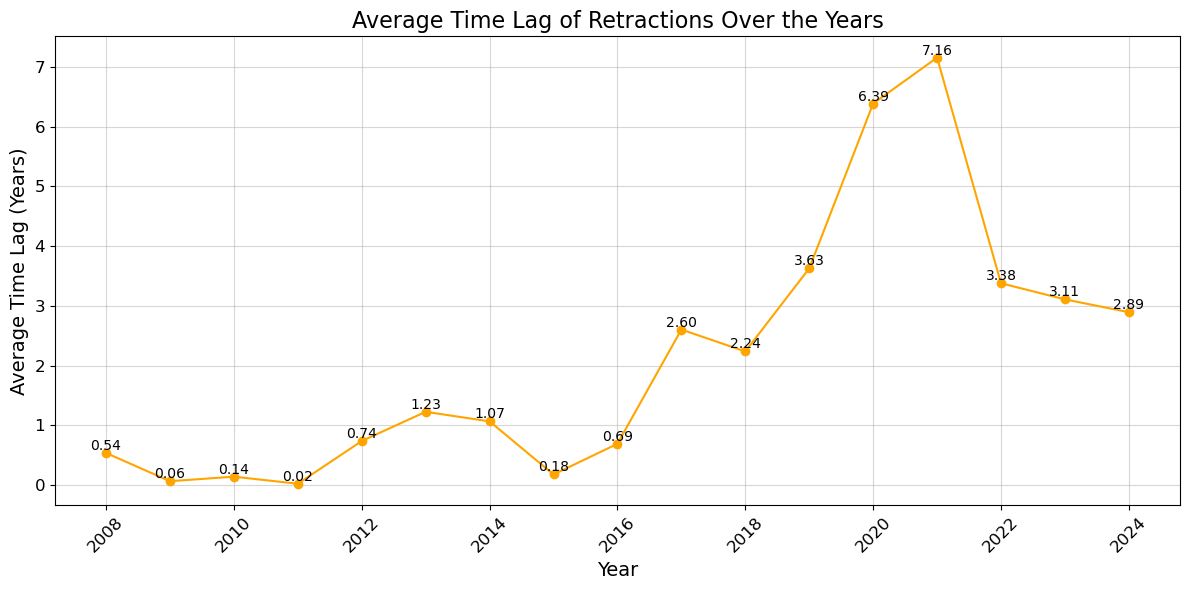

In [11]:

import matplotlib.pyplot as plt
import pandas as pd

# Convert the date columns to datetime format
data['OriginalPaperDate'] = pd.to_datetime(data['OriginalPaperDate'], errors='coerce')
data['RetractionDate'] = pd.to_datetime(data['RetractionDate'], errors='coerce')

# Calculate the time lag in years
data['TimeLag'] = (data['RetractionDate'] - data['OriginalPaperDate']).dt.days / 365.25

# Group by year of retraction and calculate the average time lag
data['RetractionYear'] = data['RetractionDate'].dt.year
avg_time_lag = data.groupby('RetractionYear')['TimeLag'].mean().reset_index(name='AverageTimeLag')

# Drop NaN values to ensure clean plotting
avg_time_lag = avg_time_lag.dropna()

# Plot the average time lag per year
plt.figure(figsize=(12, 6))
plt.plot(avg_time_lag['RetractionYear'], avg_time_lag['AverageTimeLag'], marker='o', linestyle='-', color='orange')
plt.title("Average Time Lag of Retractions Over the Years", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Average Time Lag (Years)", fontsize=14)
plt.grid(True, alpha=0.5)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

# Annotate each point with the average time lag value
for _, row in avg_time_lag.iterrows():
    plt.text(row['RetractionYear'], row['AverageTimeLag'], f"{row['AverageTimeLag']:.2f}", fontsize=10, ha='center', va='bottom')

plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

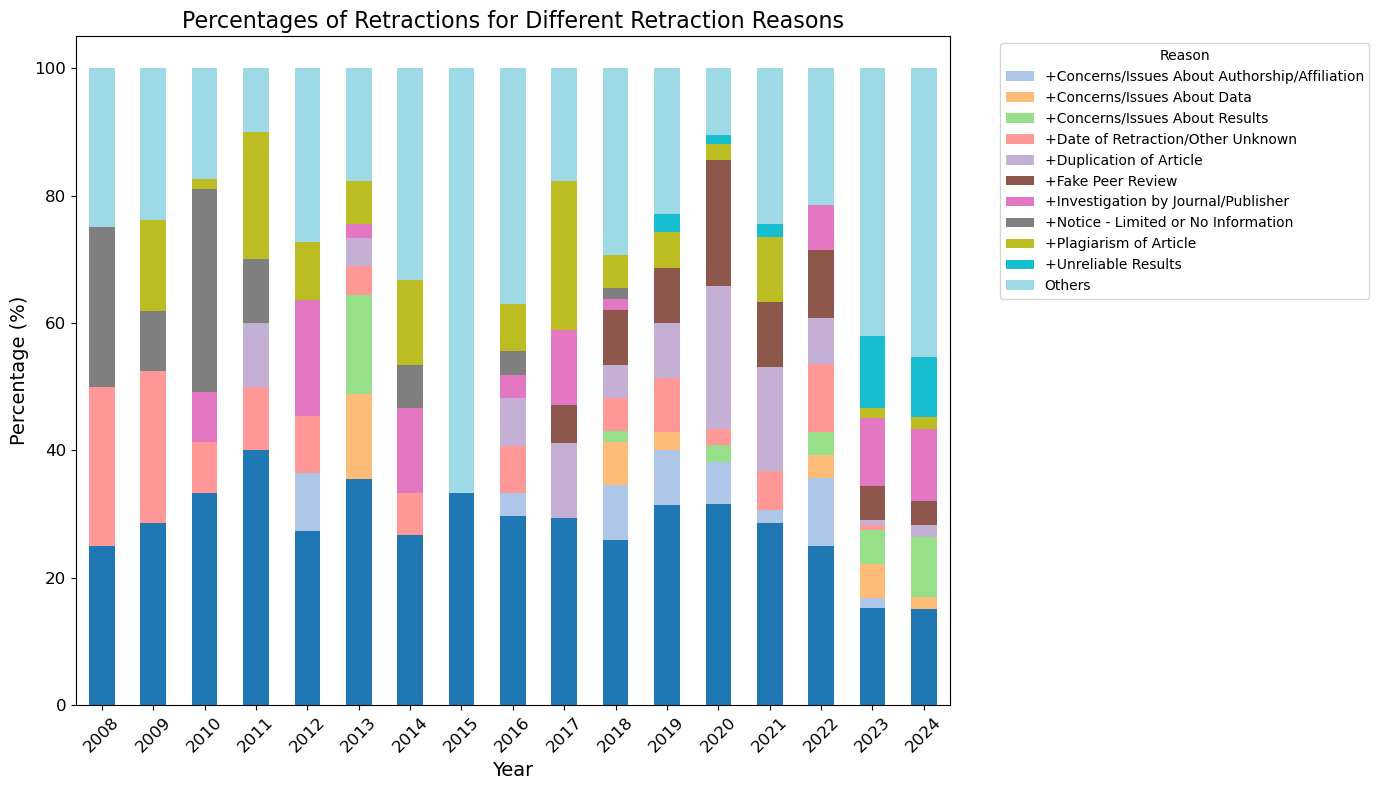

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Split the "Reason" field into multiple rows to handle multiple reasons per retraction
reasons_data = data.assign(Reason=data['Reason'].str.split(';')).explode('Reason')

# Strip any leading/trailing whitespace and filter out empty values
reasons_data['Reason'] = reasons_data['Reason'].str.strip()
reasons_data = reasons_data[reasons_data['Reason'].notna()]

# Group by reason and count occurrences to identify the top 11 reasons
top_reasons = reasons_data['Reason'].value_counts().head(11)
top_reasons_list = top_reasons.index.tolist()

# Replace less frequent reasons with "Others"
reasons_data['Reason'] = reasons_data['Reason'].apply(
    lambda x: x if x in top_reasons_list else 'Others'
)

# Group by year and reason to calculate percentages
reasons_by_year = reasons_data.groupby(['RetractionYear', 'Reason']).size().unstack(fill_value=0)
reasons_by_year_percentage = reasons_by_year.div(reasons_by_year.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart
plt.figure(figsize=(14, 8))
reasons_by_year_percentage.plot(kind='bar', stacked=True, colormap='tab20', figsize=(14, 8))
plt.title("Percentages of Retractions for Different Retraction Reasons", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)
plt.legend(title="Reason", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [27]:
reasons_data['Reason'].value_counts()

Reason
Others                                           181
                                                 169
+Duplication of Article                           42
+Fake Peer Review                                 41
+Investigation by Journal/Publisher               36
+Plagiarism of Article                            33
+Date of Retraction/Other Unknown                 33
+Notice - Limited or No Information               27
+Concerns/Issues About Results                    23
+Unreliable Results                               23
+Concerns/Issues About Authorship/Affiliation     21
+Concerns/Issues About Data                       20
Name: count, dtype: int64

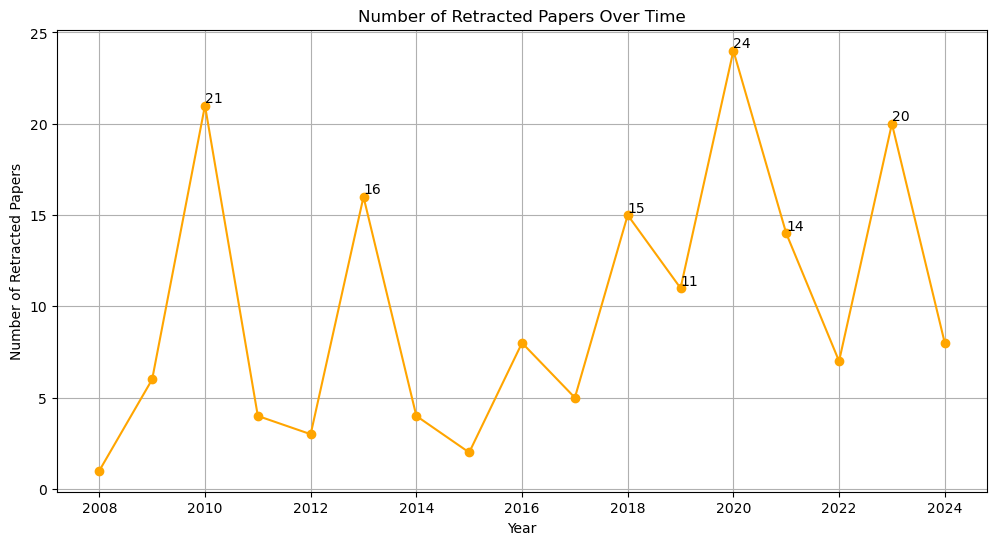

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec.csv")

# Convert RetractionDate to datetime format and extract the year
df['RetractionDate'] = pd.to_datetime(df['RetractionDate'], errors='coerce')
df['Year'] = df['RetractionDate'].dt.year

# Aggregate the number of retracted papers per year
retractions_over_time = df.groupby('Year').size()

# Create the chart
plt.figure(figsize=(12, 6))
plt.plot(retractions_over_time.index, retractions_over_time.values, marker='o', linestyle='-', color='orange')

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Number of Retracted Papers")
plt.title("Number of Retracted Papers Over Time")
plt.grid(True)

# Annotate key points
for year, count in retractions_over_time.items():
    if count > retractions_over_time.mean():  # Annotate above-average years
        plt.text(year, count, str(count), fontsize=10, verticalalignment='bottom')

# Show the plot
plt.show()

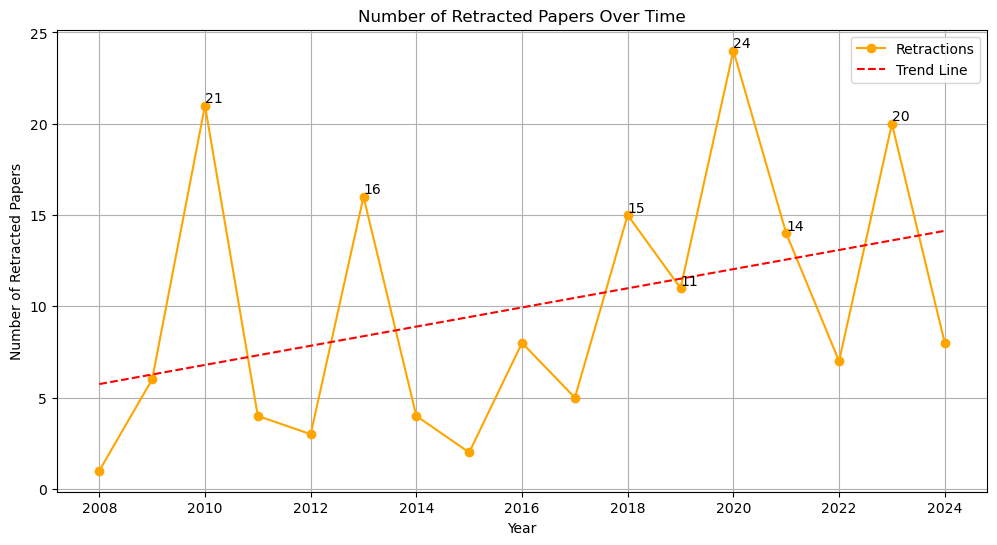

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec.csv")

# Convert RetractionDate to datetime format and extract the year
df['RetractionDate'] = pd.to_datetime(df['RetractionDate'], errors='coerce')
df['Year'] = df['RetractionDate'].dt.year

# Aggregate the number of retracted papers per year
retractions_over_time = df.groupby('Year').size()

# Create the chart
plt.figure(figsize=(12, 6))
plt.plot(retractions_over_time.index, retractions_over_time.values, marker='o', linestyle='-', color='orange', label="Retractions")

# Fit a linear trend line
x = retractions_over_time.index
y = retractions_over_time.values
z = np.polyfit(x, y, 1)  # Fit a first-degree polynomial (linear trend)
p = np.poly1d(z)

# Plot the trend line
plt.plot(x, p(x), linestyle='dashed', color='red', label="Trend Line")

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Number of Retracted Papers")
plt.title("Number of Retracted Papers Over Time")
plt.grid(True)
plt.legend()

# Annotate key points
for year, count in retractions_over_time.items():
    if count > retractions_over_time.mean():  # Annotate above-average years
        plt.text(year, count, str(count), fontsize=10, verticalalignment='bottom')

# Show the plot
plt.show()


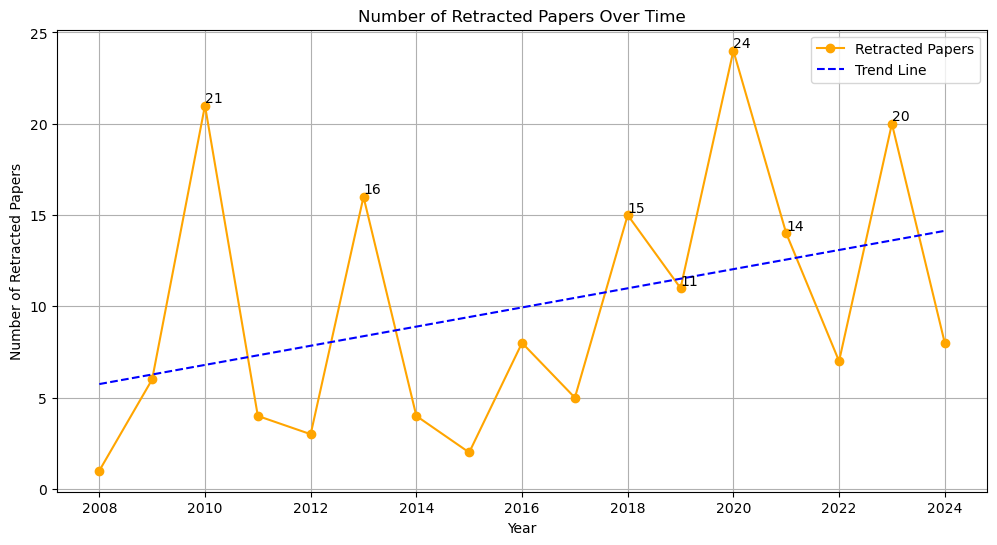

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  # <-- New import for trend calculation

df = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec.csv")

# Convert RetractionDate to datetime format and extract the year
df['RetractionDate'] = pd.to_datetime(df['RetractionDate'], errors='coerce')
df['Year'] = df['RetractionDate'].dt.year

# Aggregate the number of retracted papers per year
retractions_over_time = df.groupby('Year').size()

# Create the chart
plt.figure(figsize=(12, 6))
plt.plot(retractions_over_time.index, retractions_over_time.values, 
         marker='o', linestyle='-', color='orange', label='Retracted Papers')

# Add trend line (linear regression)
x = retractions_over_time.index.values
y = retractions_over_time.values
z = np.polyfit(x, y, 1)  # 1st degree polynomial fit
p = np.poly1d(z)
plt.plot(x, p(x), "--", color='blue', label='Trend Line')  # Dashed trend line

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Number of Retracted Papers")
plt.title("Number of Retracted Papers Over Time")
plt.grid(True)
plt.legend()  # Show legend

# Annotate key points (same as before)
for year, count in retractions_over_time.items():
    if count > retractions_over_time.mean():
        plt.text(year, count, str(count), fontsize=10, verticalalignment='bottom')

plt.show()

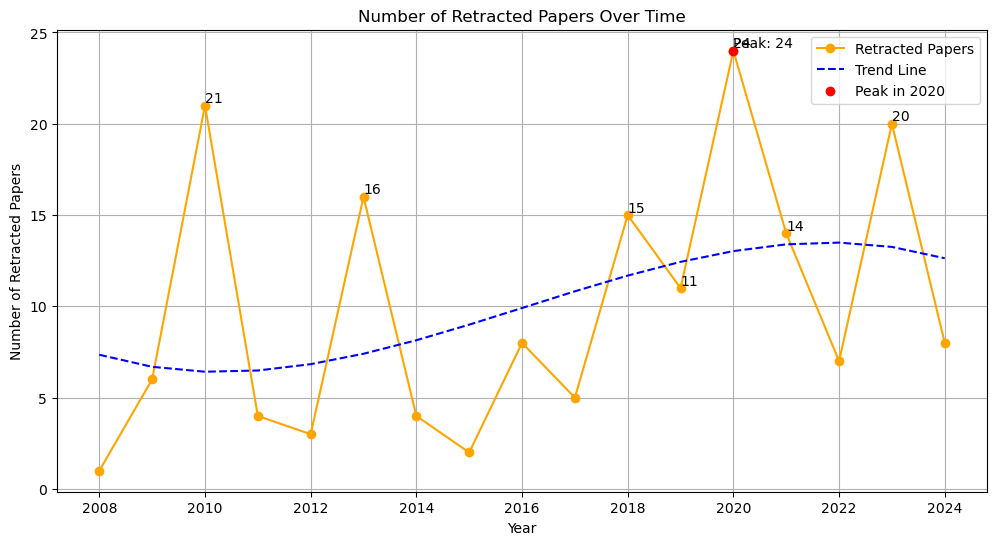

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec.csv")

# Convert RetractionDate to datetime format and extract the year
df['RetractionDate'] = pd.to_datetime(df['RetractionDate'], errors='coerce')
df['Year'] = df['RetractionDate'].dt.year

# Aggregate the number of retracted papers per year
retractions_over_time = df.groupby('Year').size()

# Create the chart
plt.figure(figsize=(12, 6))
plt.plot(retractions_over_time.index, retractions_over_time.values, marker='o', linestyle='-', color='orange', label='Retracted Papers')

# Add a trend line (polynomial fit)
x = retractions_over_time.index
y = retractions_over_time.values
z = np.polyfit(x, y, 3)  # 3rd-degree polynomial fit
p = np.poly1d(z)
plt.plot(x, p(x), linestyle='--', color='blue', label='Trend Line')

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Number of Retracted Papers")
plt.title("Number of Retracted Papers Over Time")
plt.grid(True)

# Annotate key points
for year, count in retractions_over_time.items():
    if count > retractions_over_time.mean():  # Annotate above-average years
        plt.text(year, count, str(count), fontsize=10, verticalalignment='bottom')

# Highlight the peak in 2020
peak_year = 2020
peak_value = retractions_over_time.get(peak_year, 0)
if peak_value > 0:
    plt.scatter(peak_year, peak_value, color='red', zorder=5, label='Peak in 2020')
    plt.text(peak_year, peak_value, f'Peak: {peak_value}', fontsize=10, verticalalignment='bottom')

# Add a legend
plt.legend()

# Show the plot
plt.show()

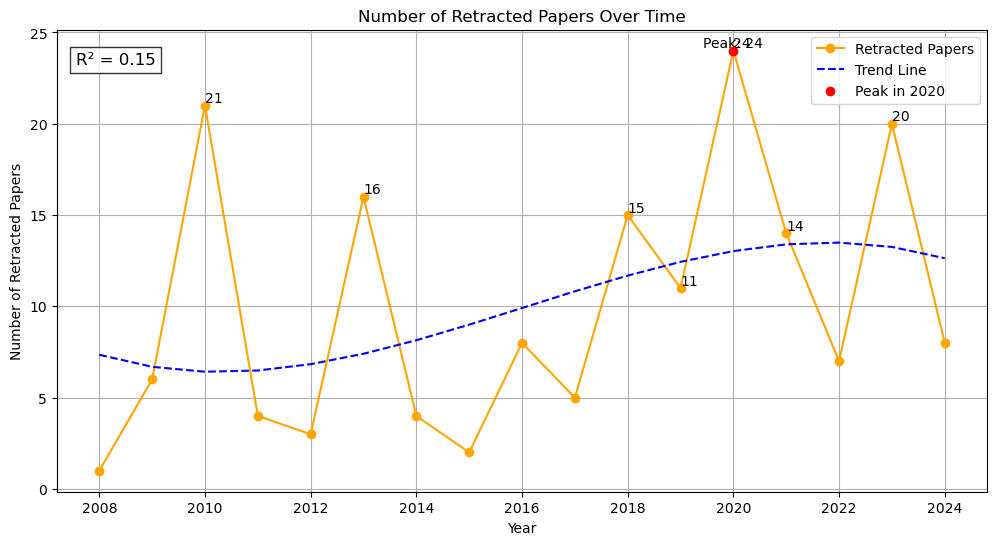

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec.csv")

# Convert RetractionDate to datetime format and extract the year
df['RetractionDate'] = pd.to_datetime(df['RetractionDate'], errors='coerce')
df['Year'] = df['RetractionDate'].dt.year

# Aggregate the number of retracted papers per year
retractions_over_time = df.groupby('Year').size()

# Create the chart
plt.figure(figsize=(12, 6))
plt.plot(retractions_over_time.index, retractions_over_time.values, marker='o', linestyle='-', color='orange', label='Retracted Papers')

# Add a trend line (polynomial fit)
x = retractions_over_time.index
y = retractions_over_time.values
z = np.polyfit(x, y, 3)  # 3rd-degree polynomial fit
p = np.poly1d(z)
plt.plot(x, p(x), linestyle='--', color='blue', label='Trend Line')

# Calculate R-squared
y_mean = np.mean(y)
ss_total = np.sum((y - y_mean) ** 2)
ss_residual = np.sum((y - p(x)) ** 2)
r_squared = 1 - (ss_residual / ss_total)

# Add R-squared value to the chart
plt.text(0.02, 0.95, f'R² = {r_squared:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Number of Retracted Papers")
plt.title("Number of Retracted Papers Over Time")
plt.grid(True)

# Annotate key points
for year, count in retractions_over_time.items():
    if count > retractions_over_time.mean():  # Annotate above-average years
        plt.text(year, count, str(count), fontsize=10, verticalalignment='bottom')

# Highlight the peak in 2020
peak_year = 2020
peak_value = retractions_over_time.get(peak_year, 0)
if peak_value > 0:
    plt.scatter(peak_year, peak_value, color='red', zorder=5, label='Peak in 2020')
    plt.text(peak_year, peak_value, f'Peak: {peak_value}', fontsize=10, verticalalignment='bottom')

# Add a legend
plt.legend()

# Show the plot
plt.show()

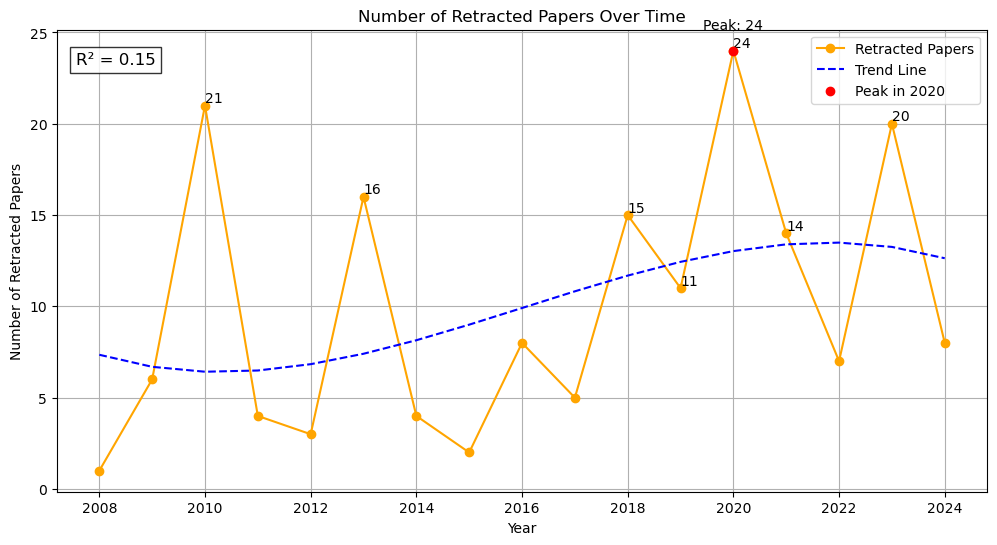

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec.csv")

# Convert RetractionDate to datetime format and extract the year
df['RetractionDate'] = pd.to_datetime(df['RetractionDate'], errors='coerce')
df['Year'] = df['RetractionDate'].dt.year

# Aggregate the number of retracted papers per year
retractions_over_time = df.groupby('Year').size()

# Create the chart
plt.figure(figsize=(12, 6))
plt.plot(retractions_over_time.index, retractions_over_time.values, marker='o', linestyle='-', color='orange', label='Retracted Papers')

# Add a trend line (polynomial fit)
x = retractions_over_time.index
y = retractions_over_time.values
z = np.polyfit(x, y, 3)  # 3rd-degree polynomial fit
p = np.poly1d(z)
plt.plot(x, p(x), linestyle='--', color='blue', label='Trend Line')

# Calculate R-squared
y_mean = np.mean(y)
ss_total = np.sum((y - y_mean) ** 2)
ss_residual = np.sum((y - p(x)) ** 2)
r_squared = 1 - (ss_residual / ss_total)

# Add R-squared value to the chart
plt.text(0.02, 0.95, f'R² = {r_squared:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Number of Retracted Papers")
plt.title("Number of Retracted Papers Over Time")
plt.grid(True)

# Annotate key points
for year, count in retractions_over_time.items():
    if count > retractions_over_time.mean():  # Annotate above-average years
        plt.text(year, count, str(count), fontsize=10, verticalalignment='bottom')

# Highlight the peak in 2020
peak_year = 2020
peak_value = retractions_over_time.get(peak_year, 0)
if peak_value > 0:
    plt.scatter(peak_year, peak_value, color='red', zorder=5, label='Peak in 2020')
    # Adjust annotation placement to avoid crowding
    plt.text(peak_year, peak_value + 1, f'Peak: {peak_value}', fontsize=10, verticalalignment='bottom', horizontalalignment='center')

# Add a legend
plt.legend()

# Show the plot
plt.show()

In [8]:
df['Publisher'].unique()

array(['Hindawi', 'Springer', 'Elsevier', 'Oxford Academic', 'Emerald',
       'Springer - Nature Publishing Group',
       'IEEE: Institute of Electrical and Electronics Engineers', 'PLoS',
       'Taylor and Francis', 'JVE International', 'SAGE Publications',
       'Wiley',
       'Fundacja Cement, Wapno, Beton (Foundation Cement, Lime, Concrete)',
       'Center of Excellence in Nonlinear Analysis and Optimization',
       'University of El Qued', 'University of Nis',
       'Academy of Science of South Africa',
       'IOS Press (bought by Sage November 2023)',
       'World Scientific Publishing Company'], dtype=object)

In [ ]:
# Re-process retraction reasons with multiple entries per row

# Split reasons into multiple rows and count occurrences
retraction_reasons_expanded = df["Reason"].str.split(";", expand=True).stack().str.strip()
retraction_reasons_counts = retraction_reasons_expanded.value_counts()

# Plot reasons for retractions with improved labeling
plt.figure(figsize=(12, 6))
retraction_reasons_counts.plot(kind="bar", color="red", alpha=0.7)
plt.xlabel("Retraction Reasons")
plt.ylabel("Count")
plt.title("Reasons for Retraction (Expanded)")
plt.xticks(rotation=45, ha="right")

# Ensure left-most bar has a proper label
plt.xticks(ticks=range(len(retraction_reasons_counts)), labels=retraction_reasons_counts.index, rotation=90, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [12]:
retraction_reasons_expanded = df["Reason"].str.split(";", expand=True).stack().str.strip()

In [ ]:
retraction_reasons_expanded

0    0                        +Concerns/Issues About Data
     1                     +Concerns/Issues About Results
     2    +Concerns/Issues about Referencing/Attributions
     3                  +Concerns/Issues with Peer Review
     4                +Investigation by Journal/Publisher
                               ...                       
167  1                                                   
168  0                     +Concerns/Issues About Results
     1                                +Plagiarism of Data
     2                                +Plagiarism of Text
     3                                                   
Length: 649, dtype: object

<Figure size 1400x800 with 0 Axes>

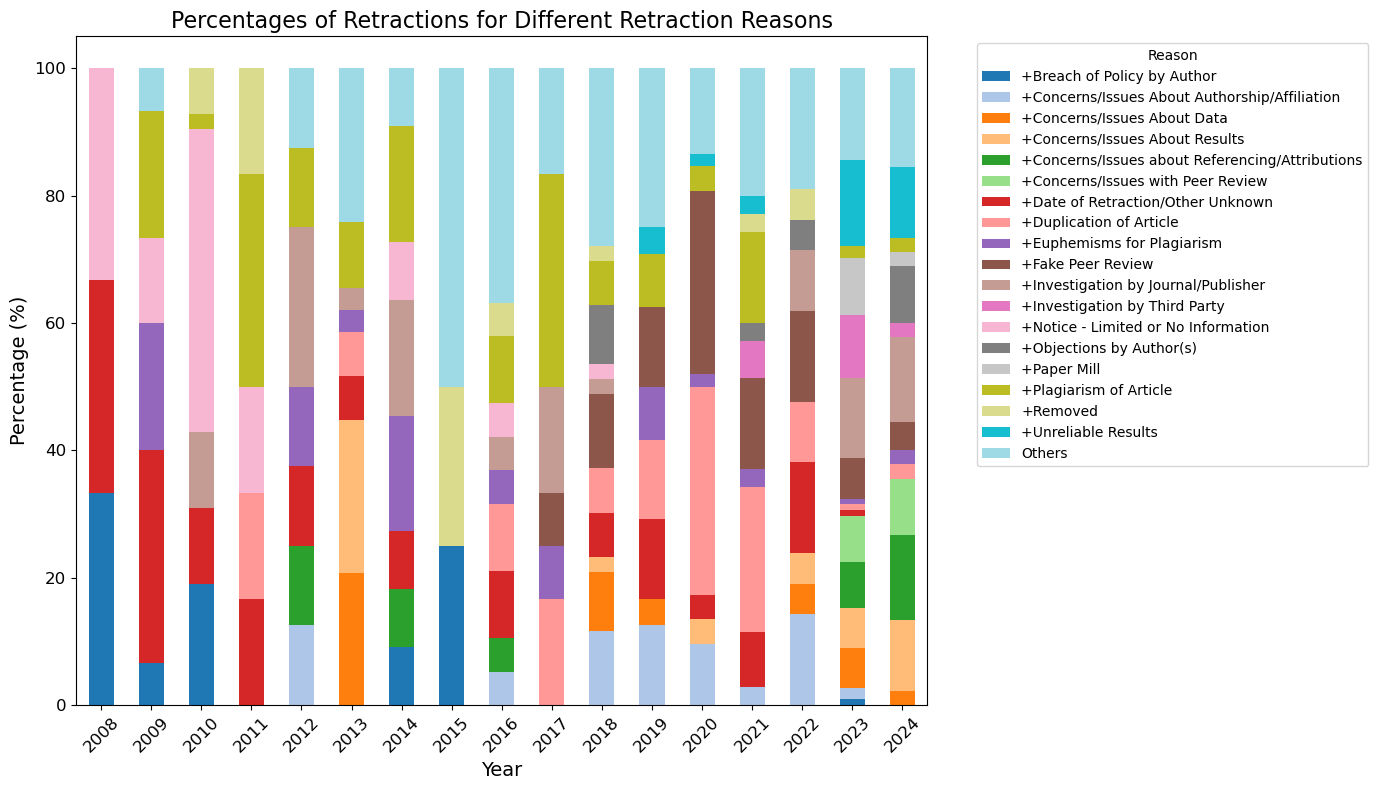

In [28]:
# Convert RetractionDate to year format
data['RetractionYear'] = pd.to_datetime(data['RetractionDate'], errors='coerce').dt.year

# Split the "Reason" field into multiple rows
reasons_data = data.assign(Reason=data['Reason'].str.split(';')).explode('Reason')
reasons_data = reasons_data[reasons_data['Reason'].str.strip() != ""]
# Clean up the reasons column
reasons_data['Reason'] = reasons_data['Reason'].str.strip()
reasons_data = reasons_data[reasons_data['Reason'].notna() & (reasons_data['Reason'] != '')]

# Group by reason and count occurrences to identify the top 11 reasons
top_reasons = reasons_data['Reason'].value_counts().head(18)
top_reasons_list = top_reasons.index.tolist()

# Replace less frequent reasons with "Others"
reasons_data['Reason'] = reasons_data['Reason'].apply(
    lambda x: x if x in top_reasons_list else 'Others'
)

# Group by year and reason to calculate percentages
reasons_by_year = reasons_data.groupby(['RetractionYear', 'Reason']).size().unstack(fill_value=0)
reasons_by_year_percentage = reasons_by_year.div(reasons_by_year.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart
plt.figure(figsize=(14, 8))
ax = reasons_by_year_percentage.plot(kind='bar', stacked=True, colormap='tab20', figsize=(14, 8))

# Adjust legend to fit all labels
plt.title("Percentages of Retractions for Different Retraction Reasons", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)
plt.legend(title="Reason", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

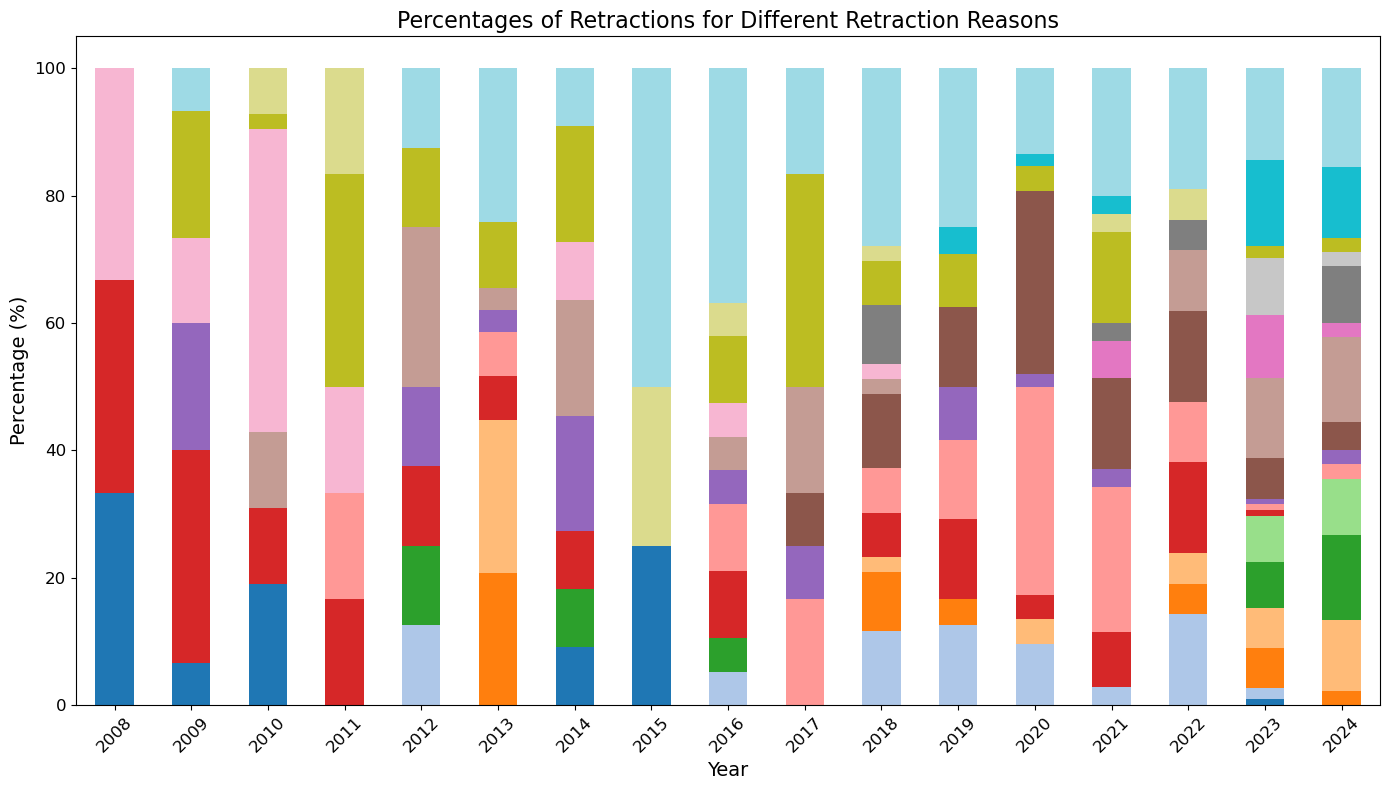

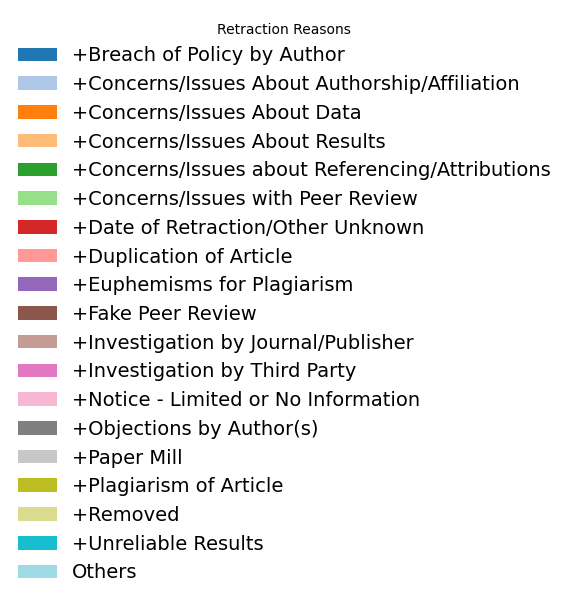

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert RetractionDate to year format
data['RetractionYear'] = pd.to_datetime(data['RetractionDate'], errors='coerce').dt.year

# Split the "Reason" field into multiple rows
reasons_data = data.assign(Reason=data['Reason'].str.split(';')).explode('Reason')
reasons_data = reasons_data[reasons_data['Reason'].str.strip() != ""]
# Clean up the reasons column
reasons_data['Reason'] = reasons_data['Reason'].str.strip()
reasons_data = reasons_data[reasons_data['Reason'].notna() & (reasons_data['Reason'] != '')]

# Group by reason and count occurrences to identify the top 18 reasons
top_reasons = reasons_data['Reason'].value_counts().head(18)
top_reasons_list = top_reasons.index.tolist()

# Replace less frequent reasons with "Others"
reasons_data['Reason'] = reasons_data['Reason'].apply(
    lambda x: x if x in top_reasons_list else 'Others'
)

# Group by year and reason to calculate percentages
reasons_by_year = reasons_data.groupby(['RetractionYear', 'Reason']).size().unstack(fill_value=0)
reasons_by_year_percentage = reasons_by_year.div(reasons_by_year.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart (without legend)
fig, ax = plt.subplots(figsize=(14, 8))
reasons_by_year_percentage.plot(kind='bar', stacked=True, colormap='tab20', ax=ax)

plt.title("Percentages of Retractions for Different Retraction Reasons", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# Extract the legend handles and labels
handles, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()  # Remove legend from the main plot

# Save the main plot
plt.savefig("stacked_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

# Create a separate figure for the legend
fig_legend, ax_legend = plt.subplots(figsize=(4, len(labels) * 0.4))  # Adjust figure size based on label count
ax_legend.axis("off")  # Hide axes

# Create and save the legend separately with larger font size
legend = ax_legend.legend(handles, labels, loc="center", title="Retraction Reasons", prop={'size': 14}, frameon=False)
plt.savefig("legend.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
reasons_data

AttributeError: 'DataFrame' object has no attribute 'unique'

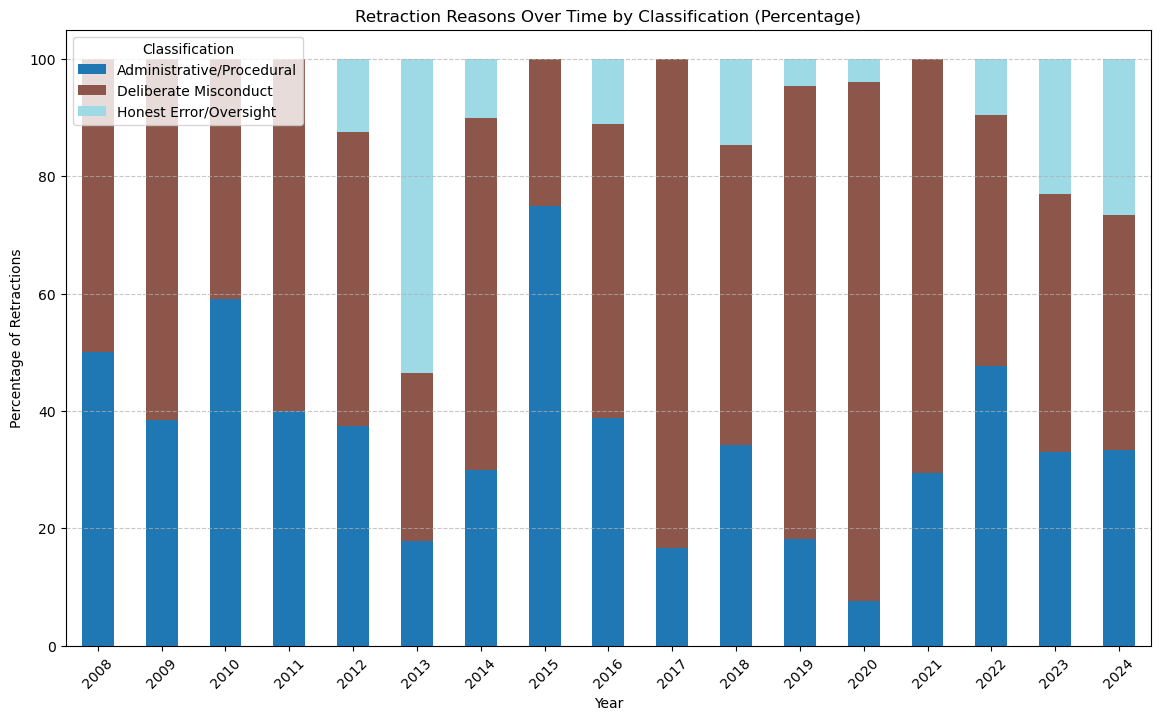

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
retracted_articles_path = r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\finalTopic\retracted_compDataElec.csv"
retraction_reasons_path = r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\finalTopic\Retraction_Reasons_Categorization_o3MiniHigh.csv"

# Read the datasets
retracted_articles_df = pd.read_csv(retracted_articles_path, encoding='latin1')
retraction_reasons_df = pd.read_csv(retraction_reasons_path, encoding='latin1')

# Convert the RetractionDate to datetime format
retracted_articles_df["RetractionDate"] = pd.to_datetime(retracted_articles_df["RetractionDate"], errors="coerce")

# Extract the year
retracted_articles_df["Year"] = retracted_articles_df["RetractionDate"].dt.year

# Split and clean the "Reason" column
retracted_articles_df["Reason"] = retracted_articles_df["Reason"].str.split(";")
retracted_articles_df = retracted_articles_df.explode("Reason")
retracted_articles_df["Reason"] = retracted_articles_df["Reason"].str.strip().str.lstrip("+-")

# Merge with retraction reasons classification
merged_df = retracted_articles_df.merge(
    retraction_reasons_df,
    left_on="Reason",
    right_on="Retraction Reason",
    how="left"
)

# Group by year and classification to count occurrences
classification_counts = merged_df.groupby(["Year", "Classification"]).size().unstack(fill_value=0)

# Convert counts to percentages
classification_percentage = classification_counts.div(classification_counts.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart with percentages
classification_percentage.plot(kind='bar', stacked=True, colormap='tab20', figsize=(14, 8))

# Customize the plot
plt.title("Retraction Reasons Over Time by Classification (Percentage)")
plt.xlabel("Year")
plt.ylabel("Percentage of Retractions")
plt.legend(title="Classification")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Show the plot
plt.show()

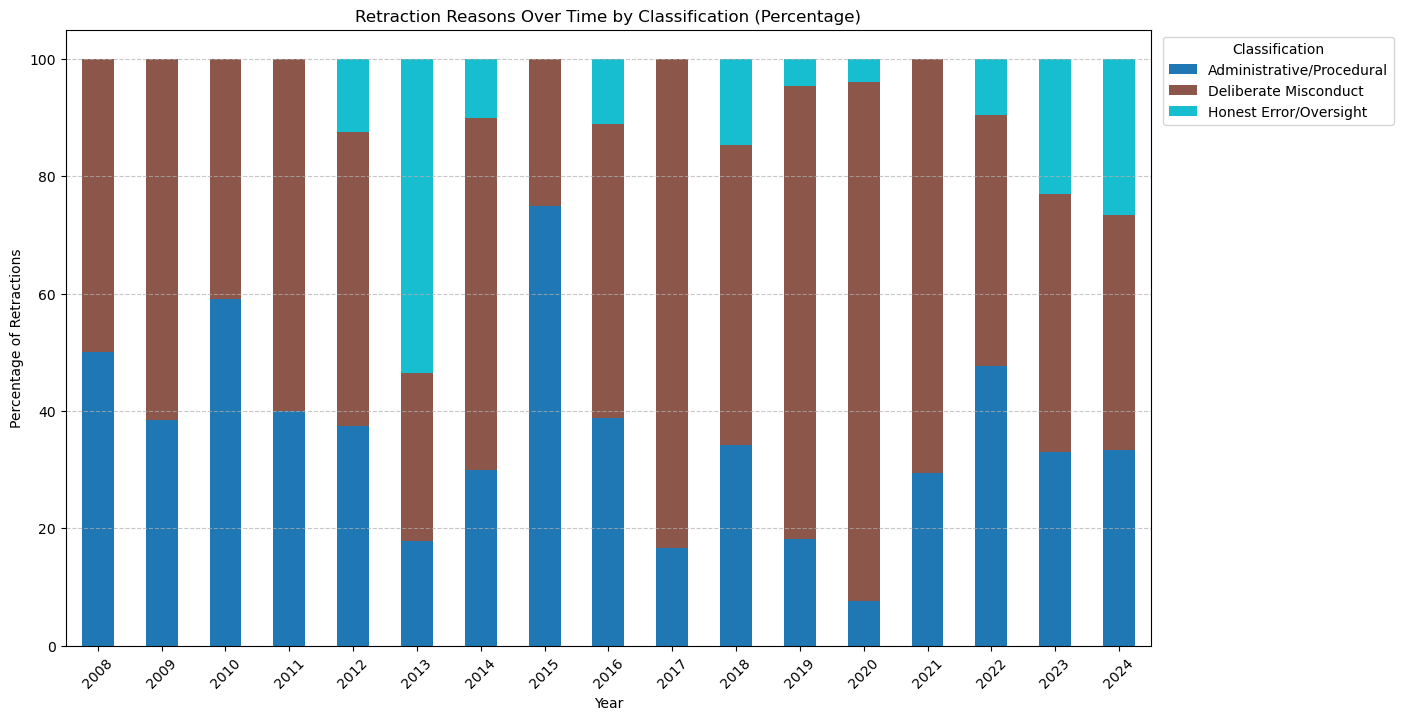

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
retracted_articles_path = r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\finalTopic\retracted_compDataElec.csv"
retraction_reasons_path = r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\finalTopic\Retraction_Reasons_Categorization_o3MiniHigh.csv"

# Read the datasets
retracted_articles_df = pd.read_csv(retracted_articles_path, encoding='latin1')
retraction_reasons_df = pd.read_csv(retraction_reasons_path, encoding='latin1')


# Convert the RetractionDate to datetime format
retracted_articles_df["RetractionDate"] = pd.to_datetime(retracted_articles_df["RetractionDate"], errors="coerce")

# Extract the year
retracted_articles_df["Year"] = retracted_articles_df["RetractionDate"].dt.year

# Split and clean the "Reason" column
retracted_articles_df["Reason"] = retracted_articles_df["Reason"].str.split(";")
retracted_articles_df = retracted_articles_df.explode("Reason")
retracted_articles_df["Reason"] = retracted_articles_df["Reason"].str.strip().str.lstrip("+-")

# Merge with retraction reasons classification
merged_df = retracted_articles_df.merge(
    retraction_reasons_df,
    left_on="Reason",
    right_on="Retraction Reason",
    how="left"
)

# Group by year and classification to count occurrences
classification_counts = merged_df.groupby(["Year", "Classification"]).size().unstack(fill_value=0)

# Convert counts to percentages
classification_percentage = classification_counts.div(classification_counts.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart with percentages
ax = classification_percentage.plot(kind='bar', stacked=True, colormap='tab10', figsize=(14, 8))

# Customize the plot
plt.title("Retraction Reasons Over Time by Classification (Percentage)")
plt.xlabel("Year")
plt.ylabel("Percentage of Retractions")
plt.legend(title="Classification", loc='upper right', bbox_to_anchor=(1.23, 1))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Show the plot
plt.show()


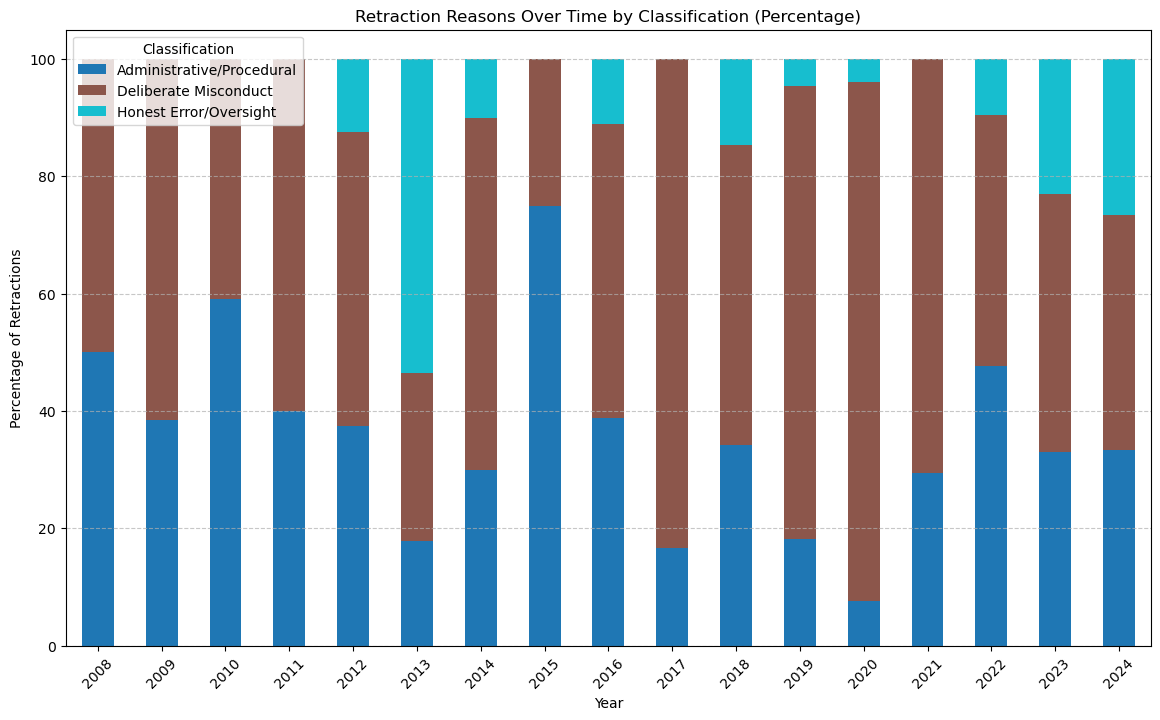

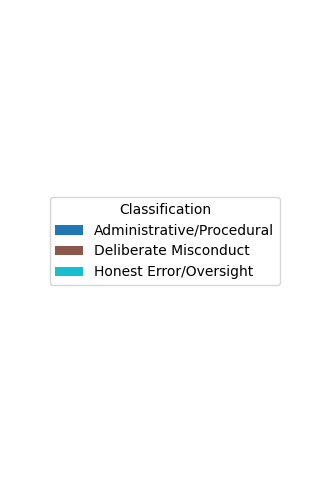

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
retracted_articles_path = r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\finalTopic\retracted_compDataElec.csv"
retraction_reasons_path = r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\finalTopic\Retraction_Reasons_Categorization_o3MiniHigh.csv"

# Read the datasets
retracted_articles_df = pd.read_csv(retracted_articles_path, encoding='latin1')
retraction_reasons_df = pd.read_csv(retraction_reasons_path, encoding='latin1')

# Convert the RetractionDate to datetime format
retracted_articles_df["RetractionDate"] = pd.to_datetime(retracted_articles_df["RetractionDate"], errors="coerce")

# Extract the year
retracted_articles_df["Year"] = retracted_articles_df["RetractionDate"].dt.year

# Split and clean the "Reason" column
retracted_articles_df["Reason"] = retracted_articles_df["Reason"].str.split(";")
retracted_articles_df = retracted_articles_df.explode("Reason")
retracted_articles_df["Reason"] = retracted_articles_df["Reason"].str.strip().str.lstrip("+-")

# Merge with retraction reasons classification
merged_df = retracted_articles_df.merge(
    retraction_reasons_df,
    left_on="Reason",
    right_on="Retraction Reason",
    how="left"
)

# Group by year and classification to count occurrences
classification_counts = merged_df.groupby(["Year", "Classification"]).size().unstack(fill_value=0)

# Convert counts to percentages
classification_percentage = classification_counts.div(classification_counts.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart with percentages
fig, ax = plt.subplots(figsize=(14, 8))
classification_percentage.plot(kind='bar', stacked=True, colormap='tab10', ax=ax)

# Customize the plot
ax.set_title("Retraction Reasons Over Time by Classification (Percentage)")
ax.set_xlabel("Year")
ax.set_ylabel("Percentage of Retractions")
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)  # Rotate x-axis labels for better readability

# Create a separate figure for the legend
fig_legend = plt.figure(figsize=(4, 6))
ax_legend = fig_legend.add_subplot(111)

# Add the legend to the new figure
handles, labels = ax.get_legend_handles_labels()
ax_legend.legend(handles, labels, title="Classification", loc='center')

# Hide axes for the legend figure
ax_legend.axis('off')

# Show the plots
plt.show()

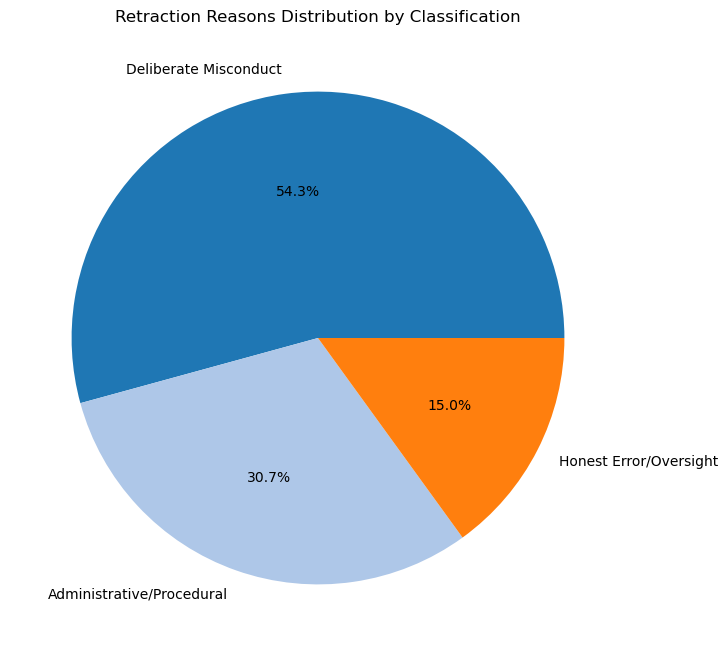

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
retracted_articles_path = r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\finalTopic\retracted_compDataElec.csv"
retraction_reasons_path = r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\finalTopic\Retraction_Reasons_Categorization_o3MiniHigh.csv"

# Read the datasets
retracted_articles_df = pd.read_csv(retracted_articles_path, encoding='latin1')
retraction_reasons_df = pd.read_csv(retraction_reasons_path, encoding='latin1')

# Convert the RetractionDate to datetime format
retracted_articles_df["RetractionDate"] = pd.to_datetime(retracted_articles_df["RetractionDate"], errors="coerce")

# Extract the year
retracted_articles_df["Year"] = retracted_articles_df["RetractionDate"].dt.year

# Split and clean the "Reason" column
retracted_articles_df["Reason"] = retracted_articles_df["Reason"].str.split(";")
retracted_articles_df = retracted_articles_df.explode("Reason")
retracted_articles_df["Reason"] = retracted_articles_df["Reason"].str.strip().str.lstrip("+-")

# Merge with retraction reasons classification
merged_df = retracted_articles_df.merge(
    retraction_reasons_df,
    left_on="Reason",
    right_on="Retraction Reason",
    how="left"
)

# Group by classification to count occurrences
classification_counts = merged_df["Classification"].value_counts()

# Plot the pie chart
plt.figure(figsize=(10, 8))
plt.pie(classification_counts, labels=classification_counts.index, autopct='%1.1f%%', colors=plt.cm.tab20.colors)
plt.title("Retraction Reasons Distribution by Classification")
plt.show()


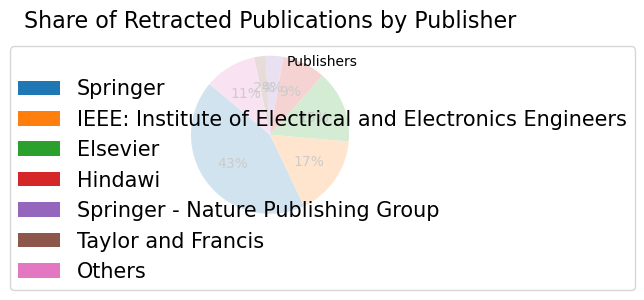

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by the 'Publisher' column and calculate the proportion of retracted publications for each publisher
publisher_counts = data['Publisher'].value_counts(normalize=True) * 100

# Select the top publishers and group others into an "Others" category
threshold = 2  # Publishers with less than 2% will be grouped into "Others"
top_publishers = publisher_counts[publisher_counts >= threshold]
others = pd.Series({'Others': publisher_counts[publisher_counts < threshold].sum()})
publisher_counts = pd.concat([top_publishers, others])

# Prepare data for the pie chart
labels = publisher_counts.index
sizes = publisher_counts.values
colors = plt.cm.tab10.colors  # Use a colormap for colors

# Plot the pie chart
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    sizes, autopct='%1.0f%%', startangle=140, colors=colors[:len(labels)]
)

# Add a legend
plt.legend(
    wedges, labels, title="Publishers", loc="upper right", bbox_to_anchor=(1.2, 0.5, 0.3, 0.5),prop={'size': 15}
)

# Add a title
plt.title("Share of Retracted Publications by Publisher", fontsize=16)

# Display the chart
plt.tight_layout()
plt.show()

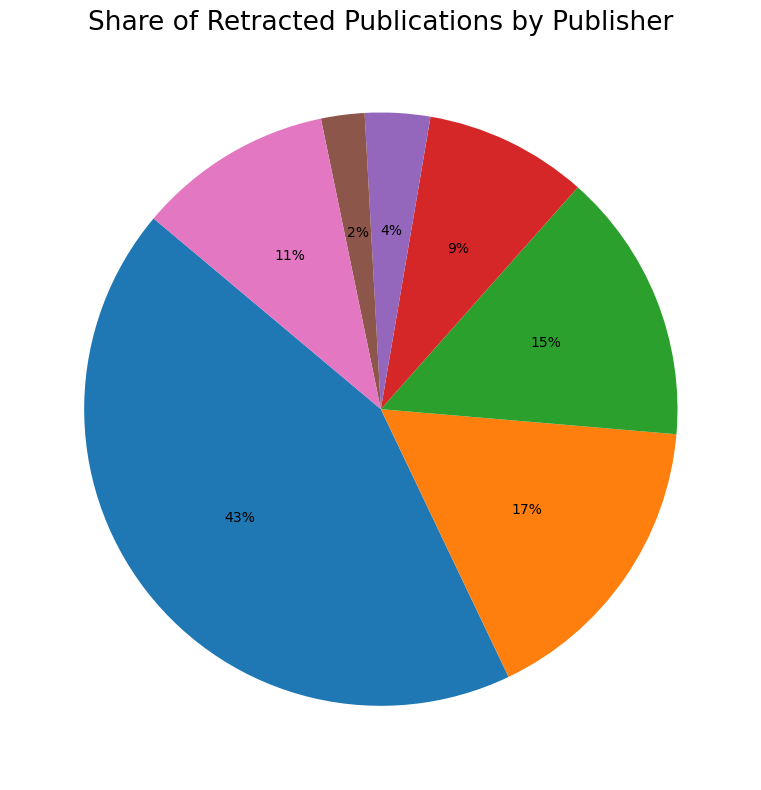

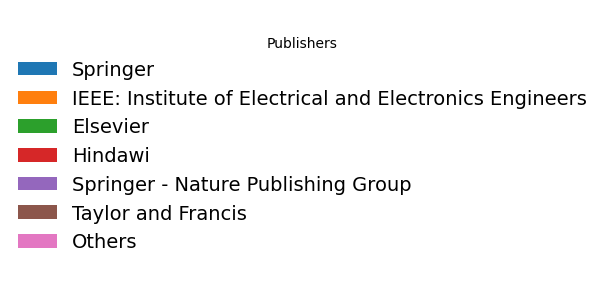

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by the 'Publisher' column and calculate the proportion of retracted publications for each publisher
publisher_counts = data['Publisher'].value_counts(normalize=True) * 100

# Select the top publishers and group others into an "Others" category
threshold = 2  # Publishers with less than 2% will be grouped into "Others"
top_publishers = publisher_counts[publisher_counts >= threshold]
others = pd.Series({'Others': publisher_counts[publisher_counts < threshold].sum()})
publisher_counts = pd.concat([top_publishers, others])

# Prepare data for the pie chart
labels = publisher_counts.index
sizes = publisher_counts.values
colors = plt.cm.tab10.colors  # Use a colormap for colors

# Create the pie chart (without legend)
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    sizes, autopct='%1.0f%%', startangle=140, colors=colors[:len(labels)]
)

# Add a title
ax.set_title("Share of Retracted Publications by Publisher", fontsize=16)

# Save the pie chart
plt.tight_layout()
plt.savefig("pie_chart.png", dpi=300)
plt.show()

# Create a separate figure for the legend
fig_legend, ax_legend = plt.subplots(figsize=(4, len(labels) * 0.5))  # Adjust size dynamically
ax_legend.axis("off")  # Hide axes

# Create and customize the legend
legend = ax_legend.legend(
    wedges, labels, loc="center", title="Publishers", prop={'size': 14}, frameon=False
)

# Save the legend as a separate image
plt.savefig("legend.png", dpi=300, bbox_inches="tight")
plt.show()


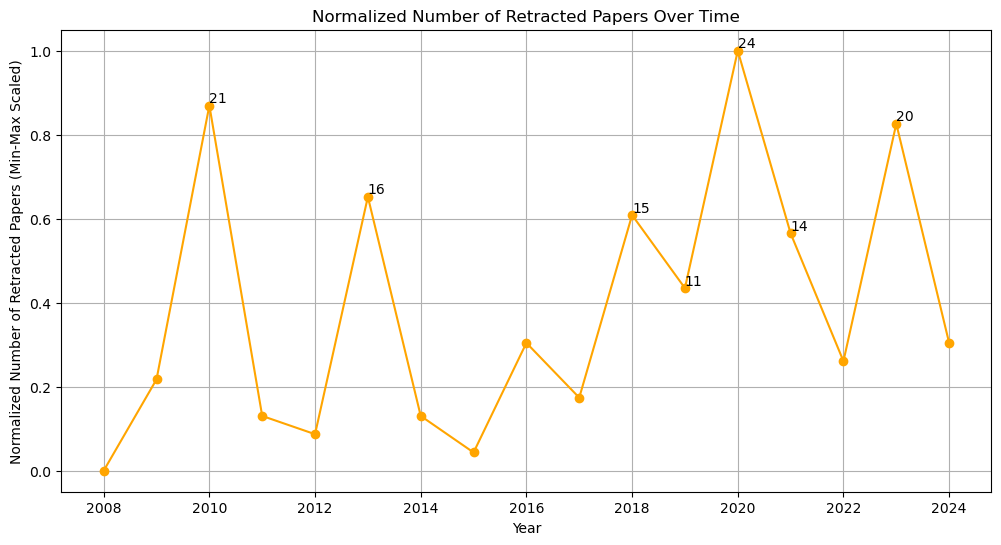

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec.csv")

# Convert RetractionDate to datetime and extract year
df['RetractionDate'] = pd.to_datetime(df['RetractionDate'], errors='coerce')
df['Year'] = df['RetractionDate'].dt.year

# Aggregate retractions per year
retractions_over_time = df.groupby('Year').size()

# Normalize retraction counts (min-max scaling)
min_retractions = retractions_over_time.min()
max_retractions = retractions_over_time.max()
normalized_retractions = (retractions_over_time - min_retractions) / (max_retractions - min_retractions)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(normalized_retractions.index, normalized_retractions.values, 
         marker='o', linestyle='-', color='orange')
plt.xlabel("Year")
plt.ylabel("Normalized Number of Retracted Papers (Min-Max Scaled)")
plt.title("Normalized Number of Retracted Papers Over Time")
plt.grid(True)

# Annotate original counts (optional)
for year, count in retractions_over_time.items():
    if count > retractions_over_time.mean():
        plt.text(year, normalized_retractions[year], f'{count}', 
                 fontsize=10, verticalalignment='bottom')

plt.show()

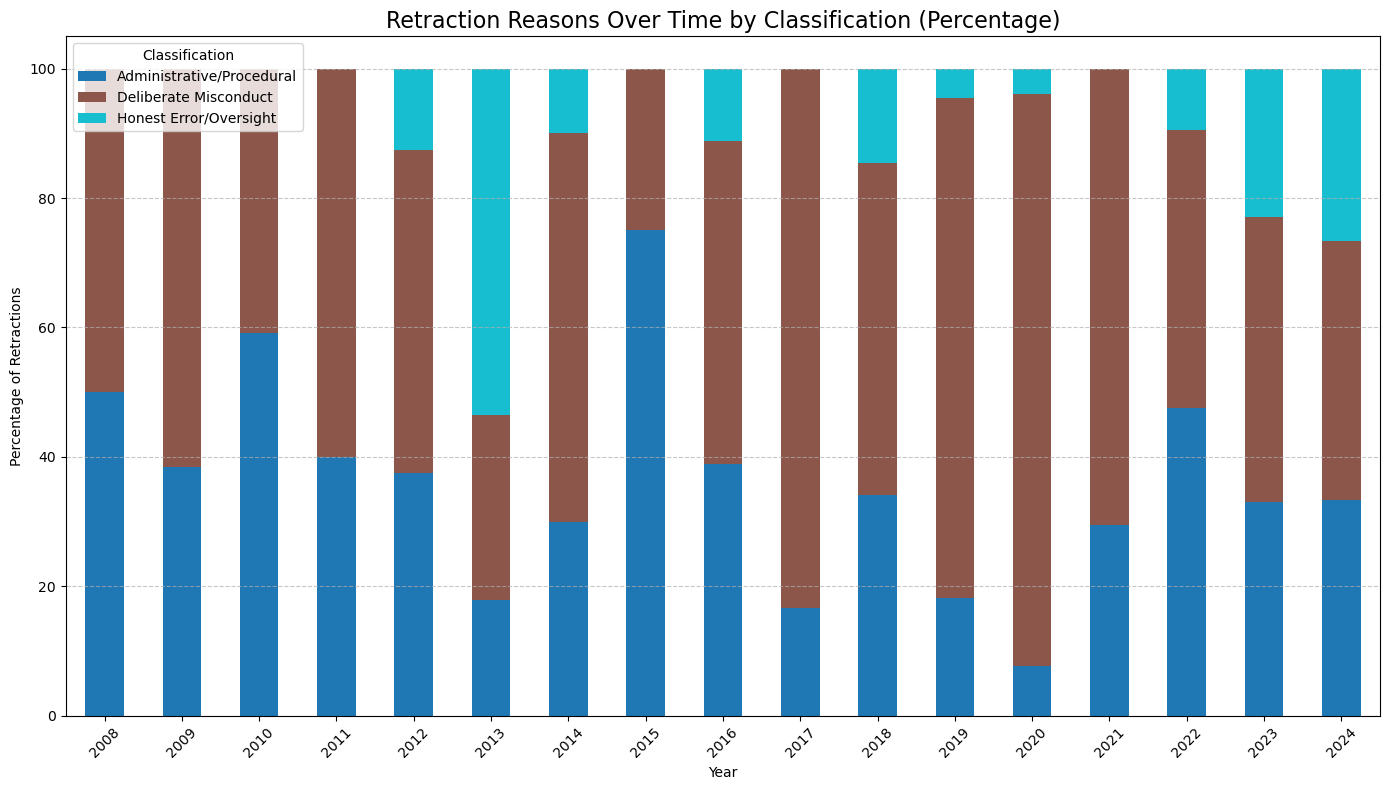

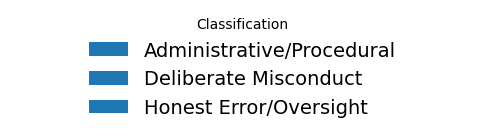

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
retracted_articles_path = r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\finalTopic\retracted_compDataElec.csv"
retraction_reasons_path = r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\finalTopic\Retraction_Reasons_Categorization_o3MiniHigh.csv"

# Read the datasets
retracted_articles_df = pd.read_csv(retracted_articles_path, encoding='latin1')
retraction_reasons_df = pd.read_csv(retraction_reasons_path, encoding='latin1')

# Convert the RetractionDate to datetime format
retracted_articles_df["RetractionDate"] = pd.to_datetime(retracted_articles_df["RetractionDate"], errors="coerce")

# Extract the year
retracted_articles_df["Year"] = retracted_articles_df["RetractionDate"].dt.year

# Split and clean the "Reason" column
retracted_articles_df["Reason"] = retracted_articles_df["Reason"].str.split(";")
retracted_articles_df = retracted_articles_df.explode("Reason")
retracted_articles_df["Reason"] = retracted_articles_df["Reason"].str.strip().str.lstrip("+-")

# Merge with retraction reasons classification
merged_df = retracted_articles_df.merge(
    retraction_reasons_df,
    left_on="Reason",
    right_on="Retraction Reason",
    how="left"
)

# Group by year and classification to count occurrences
classification_counts = merged_df.groupby(["Year", "Classification"]).size().unstack(fill_value=0)

# Convert counts to percentages
classification_percentage = classification_counts.div(classification_counts.sum(axis=1), axis=0) * 100

# Create the stacked bar chart (without legend)
fig, ax = plt.subplots(figsize=(14, 8))
bars = classification_percentage.plot(kind='bar', stacked=True, colormap='tab10', ax=ax)

# Customize the plot
ax.set_title("Retraction Reasons Over Time by Classification (Percentage)", fontsize=16)
ax.set_xlabel("Year")
ax.set_ylabel("Percentage of Retractions")
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)  # Rotate x-axis labels for readability

# Save the main plot without the legend
plt.tight_layout()
plt.savefig("retraction_reasons_chart.png", dpi=300)
plt.show()

# Create a separate figure for the legend
fig_legend, ax_legend = plt.subplots(figsize=(6, len(classification_percentage.columns) * 0.4))  # Adjust size dynamically
ax_legend.axis("off")  # Hide axes

# Create and customize the legend
legend = ax_legend.legend(
    bars.get_children(), classification_percentage.columns,
    loc="center", title="Classification", prop={'size': 14}, frameon=False
)

# Save the legend as a separate image
plt.savefig("legend.png", dpi=300, bbox_inches="tight")
plt.show()
